In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gensim
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
import keybert as kb




data_set = pd.read_csv('VKM_dataset.csv')

data_set.head()

c:\documenten\LU2-AI-Prototype\AI-PoC\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,Rood,Groen,Blauw,Geel,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,Kennismaking met Psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,In deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,4.0,2.0,1.0,5.0,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,Learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,Studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,De student toont professioneel gedrag conform ...,5.0,3.0,1.0,1.0,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,Proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,Het Jeroen Bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,NaN,NaN,NaN,NaN,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,Rouw en verlies,"Rouw & verlies, palliatieve zorg & redeneren, ...",In deze module wordt stil gestaan bij rouw en ...,In deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,Acuut complexe zorg,"Acute zorg, complexiteit, ziekenhuis, revalidatie",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19


In [3]:
data_set_copy = data_set.copy()

In [4]:
# kijken naar specifieke 'ntb' waarden in kolommen
columns_to_check = ['shortdescription', 'description', 'content', 'level', 'learningoutcomes']

for col in columns_to_check:
    count = (data_set_copy[col].str.lower() == 'ntb').sum()
    print(f"{col}: {count} keer 'ntb'")

na_count = data_set_copy['studycredit'].isna().sum()
print(f"studycredit: {na_count} missing values")

tags_count = (data_set_copy['module_tags'].str.lower() == "['ntb']").sum()
print(f"module_tags: {tags_count} keer ['ntb']")


shortdescription: 10 keer 'ntb'
description: 2 keer 'ntb'
content: 2 keer 'ntb'
level: 0 keer 'ntb'
learningoutcomes: 26 keer 'ntb'
studycredit: 0 missing values
module_tags: 10 keer ['ntb']


# Data-opschonen

In [5]:
columns_to_drop = ['Rood', 'Geel', 'Groen', 'Blauw']
if all(col in data_set_copy.columns for col in columns_to_drop):
    data_set_copy.drop(columns=columns_to_drop, inplace=True)

# Vervangen van 'ntb', 'Ntb' en "['ntb']" met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
# Vervangen van waarden die niet compleet zijn met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
values_to_replace = ['ntb', 'Ntb', "['ntb']", 'Nog niet bekend', 'nog niet bekend', 
                     "Nader te bepalen", "n.n.b.", "Nog nader te bepalen", "Nog te formuleren"]
for value in values_to_replace:
    data_set_copy.replace(value, np.nan, inplace=True)

# start_date naar datetime (foute waarden → NaT)
data_set_copy['start_date'] = pd.to_datetime(data_set_copy['start_date'], errors='coerce')

# Missende tekst invullen met eerste zin uit een andere kolom
fill_map = {
    'shortdescription': 'description',
    'description': 'shortdescription',
    'content': 'description'
}
for target, source in fill_map.items():
    data_set_copy[target] = data_set_copy[target].fillna(data_set_copy[source].str.split('.').str[0])

# Alle tekstkolommen: lowercase + trimmen
text_columns = ['shortdescription', 'description', 'content', 'learningoutcomes', 'name']
data_set_copy[text_columns] = data_set_copy[text_columns].apply(lambda col: col.str.lower().str.strip()) 


#fill missing module_tags
kw_model = kb.KeyBERT()
moduleTags = []
#datafilteren
datacopy = data_set_copy.copy()

#alle nan values module_tags krijgen
nan_module_tags = data_set_copy[data_set_copy['module_tags'].isna()]

custom_stopwords = ['de', 'het', 'een', 'en', 'van', 'op', 'in', 'met', 'voor', 'door']

# loopen door de dataset en de description eruit halen en daarna keybert gebruiken om tags te maken die toegevoegd wordt aan module_tags
for index, row in nan_module_tags.iterrows():
    text = row['description']
    keywords = kw_model.extract_keywords(text, stop_words=custom_stopwords, keyphrase_ngram_range=(1,1), top_n=3)
    tags = [kw[0] for kw in keywords]
    moduleTags.append(tags)


nan_module_tags.loc[nan_module_tags['module_tags'].isna(), 'module_tags'] = np.array(moduleTags, dtype=object)
data_set_copy['module_tags'] = data_set_copy['module_tags'].fillna(
    nan_module_tags['module_tags'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
)

# Er zijn waarden in de kolom 'module_tags' die speciale karakters bevatten zoals [ ]'. Deze heb ik verwijderd zodat de tags beter leesbaar zijn en consistent zijn.
data_set_copy['module_tags'] = data_set_copy['module_tags'].str.replace(r"[\[\]']", '', regex=True)

# dubbele rijen verwijderen uit de dataset als deze er zijn om de analyse niet te verstoren.
data_set_copy.drop_duplicates(inplace=True)

# index resetten na het verwijderen van dubbele rijen
data_set_copy.reset_index(drop=True, inplace=True)

# Nieuwe kolom 'status' toevoegen die aangeeft of de module definitief is of voorlopig op basis van missende waardes.
data_set_copy['status'] = np.where(data_set_copy.isna().any(axis=1), 'voorlopig', 'definitief')

data_set_copy.to_csv('VKM_dataset_cleaned.csv', index=False)

# Visualisatie & Trendanalyse 

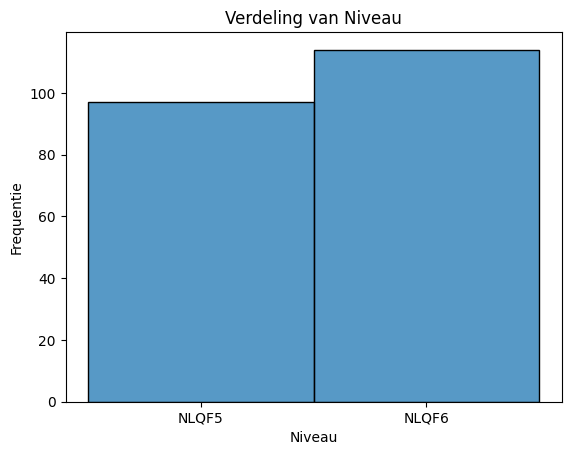

In [6]:
sns.histplot(data_set_copy['level'].dropna())
plt.title('Verdeling van Niveau')
plt.xlabel('Niveau')
plt.ylabel('Frequentie')
plt.show()

<Axes: xlabel='level', ylabel='interests_match_score'>

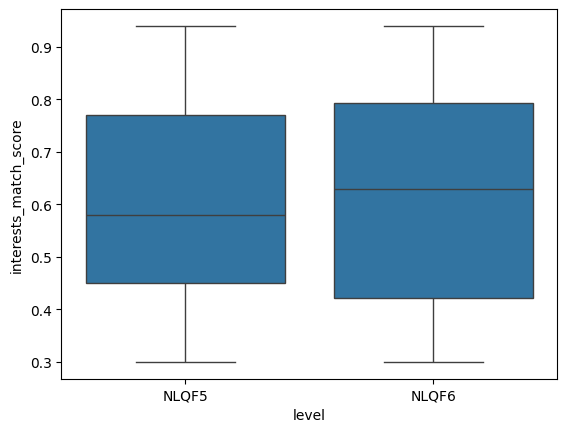

In [7]:
sns.boxplot(x='level', y='interests_match_score', data=data_set_copy)

<Axes: xlabel='status', ylabel='Count'>

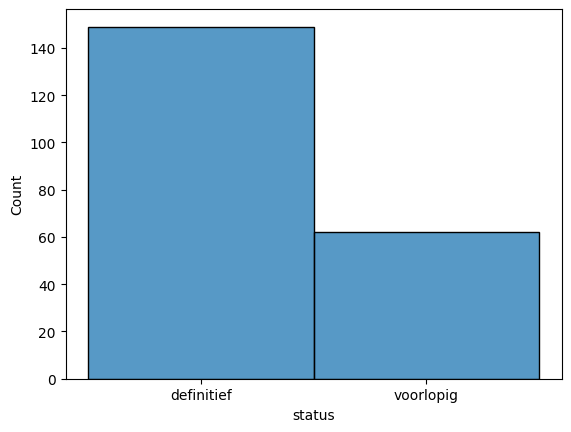

In [8]:
sns.histplot(data_set_copy['status'].dropna(), bins=20)

<Axes: xlabel='level', ylabel='estimated_difficulty'>

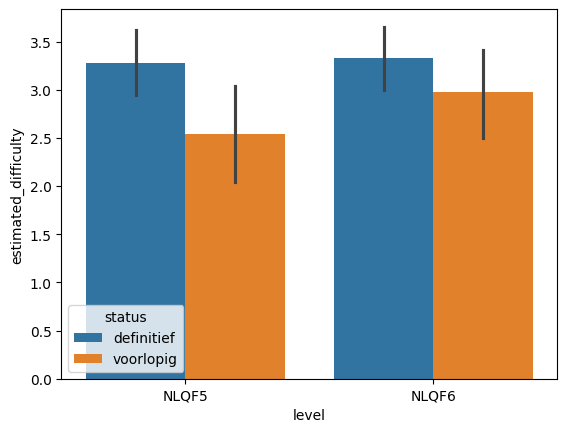

In [9]:
sns.barplot(x='level', y='estimated_difficulty', hue='status', data=data_set_copy)

<Axes: >

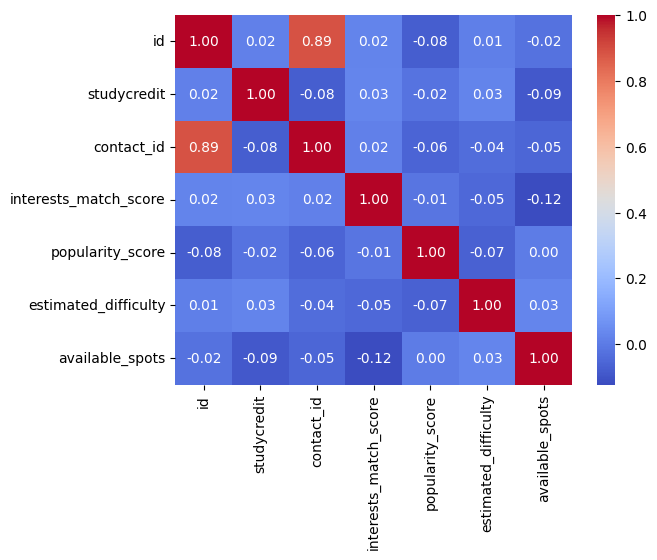

In [10]:
sns.heatmap(data_set_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

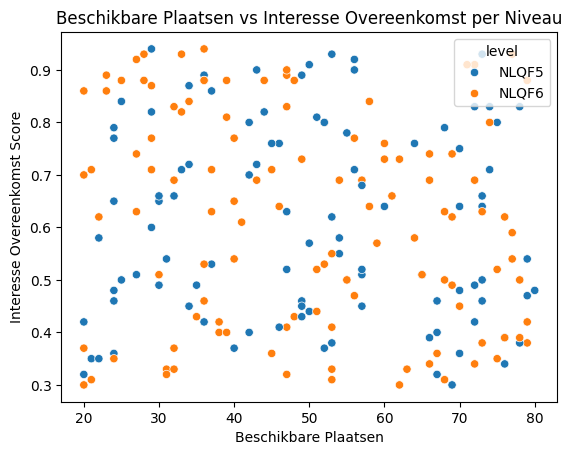

In [11]:
sns.scatterplot(x='available_spots', y='interests_match_score', hue='level', data=data_set_copy)
plt.title('Beschikbare Plaatsen vs Interesse Overeenkomst per Niveau')
plt.xlabel('Beschikbare Plaatsen')
plt.ylabel('Interesse Overeenkomst Score')
plt.show()

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [13]:
X = data_set_copy.select_dtypes(include=[np.number]).dropna()
y = data_set_copy['interests_match_score'].loc[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


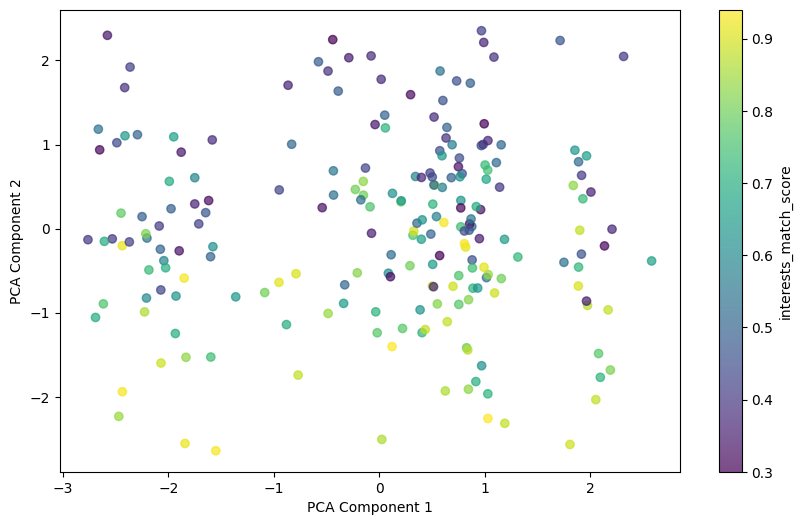

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# visualisatie van PCA-resultaten
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label='interests_match_score')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

c:\documenten\LU2-AI-Prototype\AI-PoC\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


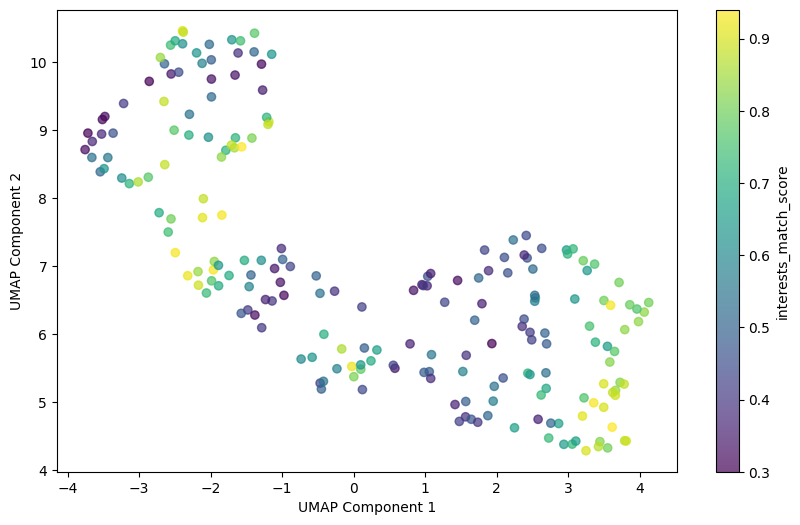

In [15]:
umap = UMAP(n_components=2, random_state=42)
X_umap = umap.fit_transform(X_scaled)

# visualisatie van UMAP-resultaten
plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label='interests_match_score')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

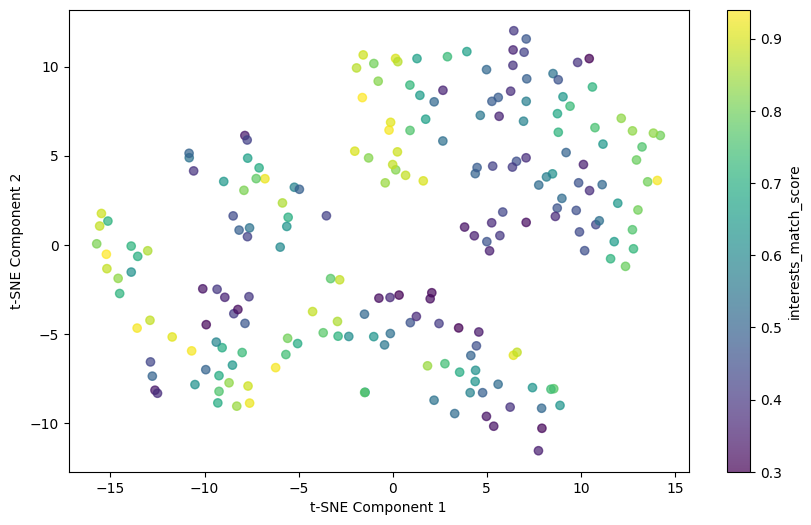

In [16]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# visualisatie van t-SNE-resultaten
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label='interests_match_score')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

# Hybrid-Recommender model

## Train data_set

In [17]:
features = ["studycredit", "estimated_difficulty", "available_spots", "interests_match_score"]
target_col = "popularity_score"

X = data_set_copy[features]
y = data_set_copy[target_col]

In [18]:
dt = DecisionTreeRegressor(random_state=42, max_depth=5)
dt.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
y_pred = dt.predict(X_test)

In [22]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 27527.67956143538
R^2 Score: -0.6927073054584549


In [23]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

class HybridRecommender:
    def __init__(self, cosine_sim: float = 0.5, intrest_match: float = 0.2, tfidf_score: float = 0.2, popularity_score: float = 0.1):
        self.cosine_sim_weight = cosine_sim
        self.intrest_match_weight = intrest_match
        self.tfidf_score_weight = tfidf_score
        self.popularity_score_weight = popularity_score
        self.stop_words = set(stopwords.words('dutch'))
        self.vectorizer = TfidfVectorizer()
        self.fitted = False
        self.feature_cols = [
            'cosine_sim_norm',
            'interest_match_norm',
            'tfidf_score_norm',
            'popularity_score_norm'
        ]

    def _preprocess_text(self, text: str) -> str:
        text_lower = text.lower()
        text_no_numbers = re.sub(r'\d+', '', text_lower)
        text_no_punct = re.sub(r'[^\w\s]', '', text_no_numbers)
        tokens = []
        for sentence in sent_tokenize(text_no_punct):
            words = word_tokenize(sentence)
            filtered = [w for w in words if w not in self.stop_words]
            tokens.extend(filtered)
        return ' '.join(tokens)

    def fit(self, csv_path: str):
        """Train het content-based deel (TF-IDF + basisfeatures) op de modules."""
        self.dataset = pd.read_csv(csv_path)

        # 1) combined_text maken
        self.dataset['combined_text'] = (
            self.dataset['name'].fillna('') + ' ' +
            self.dataset['shortdescription'].fillna('') + ' ' +
            self.dataset['description'].fillna('') + ' ' +
            self.dataset['content'].fillna('') + ' ' +
            self.dataset['learningoutcomes'].fillna('') + ' ' +
            self.dataset['module_tags'].fillna('')
        )

        # 2) preprocessen
        preprocessed_texts = [
            self._preprocess_text(t) for t in self.dataset['combined_text']
        ]

        # 3) TF-IDF model trainen
        self.tfidf_matrix = self.vectorizer.fit_transform(preprocessed_texts)

        # 4) tfidf_score feature maken
        self.dataset['tfidf_score'] = self.tfidf_matrix.sum(axis=1).A1

        # 5) normaliseren van vaste features
        self.dataset['interest_match_norm'] = MinMaxScaler().fit_transform(
            self.dataset['interests_match_score'].values.reshape(-1, 1)
        )
        self.dataset['popularity_score_norm'] = MinMaxScaler().fit_transform(
            self.dataset['popularity_score'].values.reshape(-1, 1)
        )
        self.dataset['tfidf_score_norm'] = MinMaxScaler().fit_transform(
            self.dataset['tfidf_score'].values.reshape(-1, 1)
        )

        self.fitted = True
        
    def recommend(self, student_input: str, top_k: int = 5):
        if not self.fitted:
            raise ValueError("Model is nog niet getraind. Roep eerst .fit(...) aan.")
        
        if np.round(self.cosine_sim_weight + self.intrest_match_weight + self.tfidf_score_weight + self.popularity_score_weight, decimals=2) != 1.0:
            raise ValueError("De gewichten moeten optellen tot 1.0")
        
        # 1) Studenttekst preprocessen
        student_text = self._preprocess_text(student_input)

        # 2) vector maken met dezelfde TF-IDF vectorizer
        student_vector = self.vectorizer.transform([student_text])

        # 3) cosine similarity berekenen
        similarities = cosine_similarity(student_vector, self.tfidf_matrix).flatten()
        self.dataset['cosine_sim'] = similarities

        # 4) cosine normaliseren
        self.dataset['cosine_sim_norm'] = MinMaxScaler().fit_transform(
            self.dataset['cosine_sim'].values.reshape(-1, 1)
        )

        # 5) baseline hybrid score (handmatig gewogen)
        self.dataset['hybrid_score_handmade'] = (
            self.cosine_sim_weight * self.dataset['cosine_sim_norm'] +
            self.intrest_match_weight * self.dataset['interest_match_norm'] +
            self.tfidf_score_weight * self.dataset['tfidf_score_norm'] +
            self.popularity_score_weight * self.dataset['popularity_score_norm']
        )

        # 6) Als er een getraind ML-model is, vervang hybrid_score
        self.dataset['hybrid_score'] = self.dataset['hybrid_score_handmade']

        # 7) top-k teruggeven
        top_modules = self.dataset.sort_values(
            by='hybrid_score', ascending=False
        ).head(top_k)

        return top_modules[['name', 'description', 'shortdescription', 'location', 'level']]


In [24]:
student_input = "zorg, gezondheid en welzijn, technologie, programmeren"

In [25]:

recommender = HybridRecommender(cosine_sim=0.5, intrest_match=0.2, tfidf_score=0.2, popularity_score=0.1)

# als je nog niet getraind hebt moet je dit doen:
  # voorbeeld DataFrame met interacties
recommender.fit('VKM_dataset_cleaned.csv')
top_rec = recommender.recommend(student_input, top_k=5)
top_rec.head()

,name,description,shortdescription,location,level
12,technologie in zorg en welzijn,een belangrijk vraagstuk voor de hedendaagse p...,"technologie, zorg, welzijn",Den Bosch,NLQF6
17,technologie die ècht werkt: innovatie in zorg ...,hoe kan technologie de beloftes waarmaken en é...,"technologie, smart health, robotica, zorg, wel...",Breda,NLQF5
13,zorg dichtbij,met 'zorg op afstand' kan je met behulp van te...,"zorg op afstand, technologie, implementeren, z...",Breda,NLQF5
77,module 3.4 duurzaam gebouwde omgeving - gezond...,student gaan aan de slag met een casus rondom ...,"interdisciplinair, wellbeing, bouwen voor de zorg",Den Bosch en Tilburg,NLQF6
31,healthcare innovation design,deze module richt zich op (product)ontwerpvraa...,"zorg, welzijn, productontwerp",Breda,NLQF6


In [26]:
# import pickle
 
# with open('hybrid_recommender_model.pkl', 'wb') as f:
#     pickle.dump(recommender, f)

# model = None
# with open('hybrid_recommender_model.pkl', 'rb') as f:
#     model = pickle.load(f)
    
# top = model.recommend(student_input, top_k=5)
# top.head()